# Praktikum Simple Linear Regression dan Multiple Linear Regression
### 4233201 Kecerdasan Buatan | Semester Ganjil TA 2026/2027
### Week/Sesi: 3/2 | Nama: Tika Altiora Sitanggang | NIM: 42324025

**Tujuan praktikum:** melatih model regresi, menentukan persamaan garis regresi, dan mengevaluasi performa model.

**Tabel 1. Dataset yang digunakan**

| Bagian | Dataset | Predictor (X) | Target (y) |
|---|---|---|---|
| Praktikum Simple Linear Regression | Salary_Data.csv | YearsExperience | Salary |
| Praktikum Multiple Linear Regression | multiple_linear_regression_dataset.csv | age, experience | income |
| Tugas 1 (Simple Linear Regression) | rounded_hours_student_scores.csv | Hours | Scores |
| Tugas 2 (Multiple Linear Regression) | Marketing_Data.csv | youtube, facebook, newspaper | sales |

## 0. Import Library
Bagian ini memanggil semua library yang dipakai sepanjang praktikum.

- `pandas` untuk membaca dan mengolah data dalam bentuk tabel (DataFrame)
- `numpy` untuk perhitungan numerik
- `matplotlib` dan `seaborn` untuk membuat grafik
- `train_test_split` untuk membagi data latih dan data uji
- `LinearRegression` untuk membuat model regresi linear
- `r2_score`, `mean_absolute_error`, `mean_squared_error` untuk menilai performa model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.dpi'] = 120  # agar grafik lebih tajam

print("Library berhasil diimport")

Library berhasil diimport


## 1. Simple Linear Regression (Praktikum)
**Simple Linear Regression** memakai **satu** variabel predictor (X) untuk memprediksi target (y) dengan persamaan garis lurus:

`ŷ = a + bx`

- `ŷ` = nilai prediksi
- `a` = intercept, yaitu nilai y saat x = 0
- `b` = slope, yaitu besar perubahan y setiap x bertambah 1 satuan

Dataset yang dipakai adalah **Salary_Data.csv**: memprediksi gaji (Salary) berdasarkan lama pengalaman kerja (YearsExperience).

### 1.1 Load Dataset
`pd.read_csv()` membaca file CSV menjadi DataFrame bernama `df`, lalu `head()` menampilkan 5 baris pertama. Dataset ini punya 2 kolom: `YearsExperience` (lama pengalaman dalam tahun) dan `Salary` (gaji).

In [2]:
df = pd.read_csv('Salary_Data.csv')
print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


### 1.2 Menentukan Predictor (X) dan Target (y)
- `df.iloc[:, :-1]` mengambil semua baris dan semua kolom **kecuali kolom terakhir**, hasilnya menjadi **X** (predictor: YearsExperience).
- `df.iloc[:, 1]` mengambil kolom indeks 1 (Salary), hasilnya menjadi **y** (target).
- `.values` mengubah data menjadi array NumPy.
- Dua baris `print` ditambahkan untuk memastikan bentuk data: X berbentuk 30 baris 1 kolom, y berisi 30 nilai.

In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)

Bentuk X: (30, 1)
Bentuk y: (30,)


### 1.3 Visualisasi Data (Scatter Plot)
Sebelum membuat model, kita lihat dulu pola datanya. Setiap titik merah mewakili satu orang. Polanya naik hampir lurus: makin lama pengalaman, makin besar gaji. Pola seperti ini cocok dimodelkan dengan regresi linear.

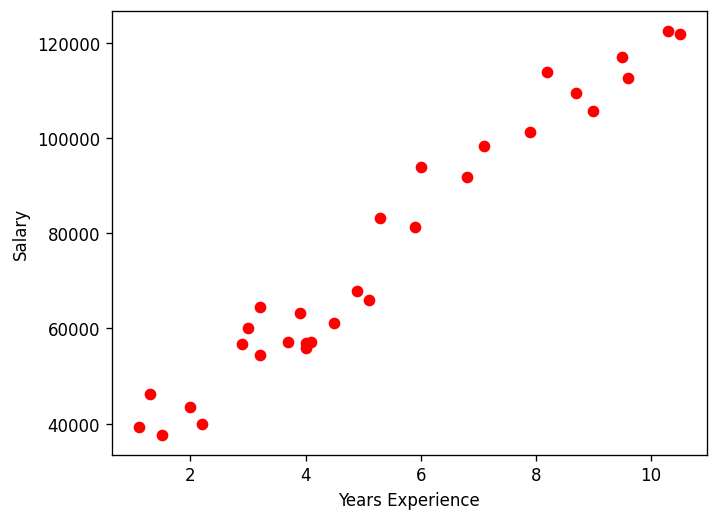

In [4]:
plt.scatter(X, y, color = "red")
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.show()

### 1.4 Membagi Data Latih dan Data Uji (80:20)
Dataset dibagi menjadi **80% data latih** (24 data) untuk melatih model dan **20% data uji** (6 data) untuk menguji model pada data yang belum pernah dilihat. `random_state = 42` dipakai supaya pembagian selalu sama, jadi hasilnya bisa direproduksi.

In [5]:
#bagi dataset jadi train dan test 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji  :", len(X_test))

Jumlah data latih: 24
Jumlah data uji  : 6


### 1.5 Melatih Model Simple Linear Regression
`LinearRegression()` membuat model, lalu `.fit(X_train, y_train)` melatihnya. Saat dilatih, model mencari **garis terbaik** dengan metode *least squares*, yaitu garis yang paling kecil total selisih kuadratnya terhadap titik-titik data. Output `LinearRegression()` menandakan model sudah terlatih.

In [6]:
# Fitting Simple Linear Regression to the Training set
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 1.6 Menentukan Persamaan Garis Regresi
- `regressor.intercept_` adalah **intercept (a)**, yaitu nilai y saat x = 0.
- `regressor.coef_[0]` adalah **slope (b)**, yaitu seberapa besar y berubah saat x naik 1 satuan.
- Keduanya disusun menjadi persamaan `ŷ = a + bx`.

In [7]:
a = regressor.intercept_
b = regressor.coef_[0]

print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
print(f"ŷ = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 25321.583011776813
Estimated model slope, b: 9423.815323030976
ŷ = 25321.58 + 9423.82x


**Interpretasi:** persamaan regresinya `ŷ = 25321.58 + 9423.82x`.
- Intercept **25321.58**: perkiraan gaji saat pengalaman kerja 0 tahun.
- Slope **9423.82**: setiap tambahan 1 tahun pengalaman, gaji naik sekitar 9423.82.

### 1.7 Memprediksi Data Uji
`regressor.predict(X_test)` memakai model yang sudah dilatih untuk memprediksi gaji pada 6 data uji. Hasilnya array berisi 6 nilai prediksi, urutannya sama dengan urutan data uji.

In [8]:
# memprediksi hasil pada data uji (Test set) menggunakan model regresi yang telah dilatih
y_pred = regressor.predict(X_test)
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

### 1.8 Perbandingan Gaji Aktual dan Prediksi (Tambahan)
Tabel ini menyandingkan gaji sebenarnya (`y_test`) dengan gaji hasil prediksi (`y_pred`) supaya selisihnya mudah dilihat. Makin dekat kedua angka, makin bagus prediksinya.

In [9]:
hasil = pd.DataFrame({
    'YearsExperience': X_test.ravel(),
    'Salary Aktual': y_test,
    'Salary Prediksi': y_pred.round(2)
})
print(hasil)

   YearsExperience  Salary Aktual  Salary Prediksi
0              9.6       112635.0        115790.21
1              4.9        67938.0         71498.28
2              8.2       113812.0        102596.87
3              5.3        83088.0         75267.80
4              3.2        64445.0         55477.79
5              3.7        57189.0         60189.70


### 1.9 Evaluasi Model dengan R-Square
**R-Square (R²)** mengukur seberapa baik model menjelaskan variasi data. Nilainya 0 sampai 1, makin mendekati 1 makin baik modelnya.

In [10]:
# Menghitung nilai R-Square, yang mengukur seberapa baik model regresi linear
# Semakin mendekati 1, semakin baik model

score = r2_score(y_test, y_pred)
score

0.9024461774180497

**Interpretasi:** R² = **0.9024**, artinya sekitar **90.2%** variasi gaji pada data uji dapat dijelaskan oleh lama pengalaman kerja. Model tergolong **sangat baik**.

### 1.10 Visualisasi Hasil pada Data Latih
Titik merah adalah data latih, garis biru adalah garis regresi hasil model. Garis melewati dekat sebagian besar titik, jadi model sudah menangkap pola datanya dengan baik.

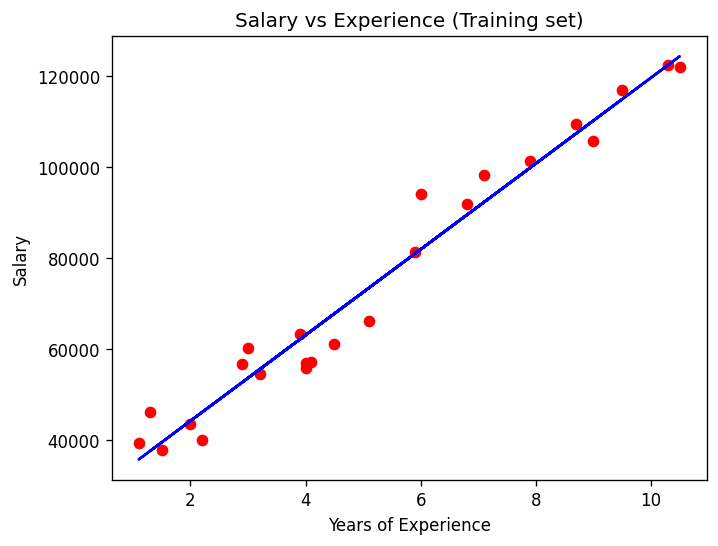

In [11]:
# Visualizing the Training set results
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

### 1.11 Visualisasi Hasil pada Data Uji
Sekarang titik merah adalah **data uji** (6 titik). Garis biru tetap garis dari model yang sama, karena modelnya hanya dilatih sekali. Titik uji yang dekat dengan garis menunjukkan model juga akurat pada data baru.

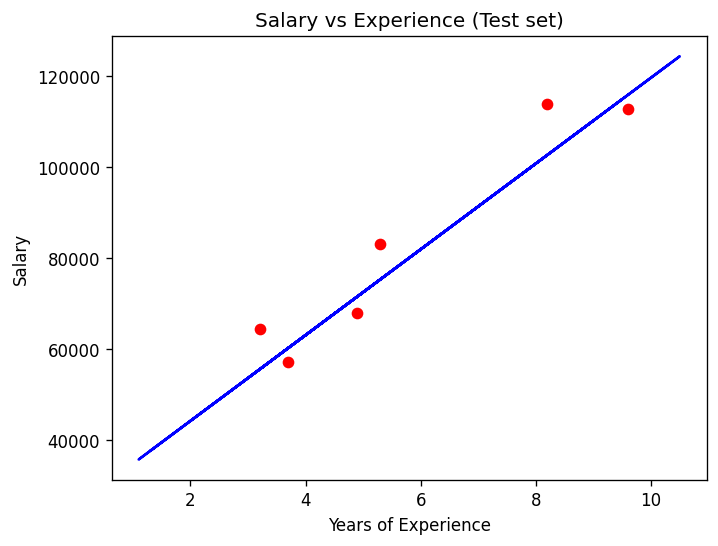

In [12]:
# Visualizing the Test set results
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## 2. Multiple Linear Regression (Praktikum)
**Multiple Linear Regression** memakai **lebih dari satu** predictor untuk memprediksi target:

`ŷ = a + b1x1 + b2x2`

Dataset yang dipakai adalah **multiple_linear_regression_dataset.csv**: memprediksi pendapatan (`income`) berdasarkan usia (`age`) dan lama pengalaman (`experience`).

### 2.1 Load Dataset
Dataset dibaca ke DataFrame `df2`. Kolomnya: `age` (usia), `experience` (pengalaman, tahun), dan `income` (pendapatan).

In [13]:
df2 = pd.read_csv('multiple_linear_regression_dataset.csv')
print(df2.head())

   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830


### 2.2 Menentukan Predictor (X) dan Target (y)
- `X2 = df2.iloc[:, :-1]` mengambil semua kolom kecuali yang terakhir, yaitu **age** dan **experience** (2 predictor).
- `y2 = df2.iloc[:, 2]` mengambil kolom indeks 2, yaitu **income** (target).

In [14]:
X2 = df2.iloc[:, :-1]
y2 = df2.iloc[:, 2]

print("Bentuk X2:", X2.shape)
print("Bentuk y2:", y2.shape)

Bentuk X2: (20, 2)
Bentuk y2: (20,)


### 2.3 Membagi Data Latih dan Data Uji (80:20)
Sama seperti sebelumnya, data dibagi 80:20 dengan `random_state = 42`. Dataset ini hanya punya 20 baris, jadi data latih 16 dan data uji 4.

In [15]:
# Bagi dataset menjadi train dan test 80:20

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 42)

print("Jumlah data latih:", len(X_train2))
print("Jumlah data uji  :", len(X_test2))

Jumlah data latih: 16
Jumlah data uji  : 4


### 2.4 Melatih Model Multiple Linear Regression
Multiple Linear Regression memakai fungsi yang sama dengan Simple Linear Regression, yaitu `LinearRegression()` dari Scikit-Learn. Bedanya, `X_train2` sekarang berisi lebih dari satu kolom.

In [16]:
regressor = LinearRegression()
regressor.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 2.5 Memprediksi Data Uji
Model memprediksi `income` untuk 4 data uji. Hasilnya berupa 4 nilai prediksi.

In [17]:
# Predicting the Test set results
y_pred2 = regressor.predict(X_test2)
print(y_pred2)

[31093.38107376 31295.49954076 40250.46080162 34897.6958918 ]


### 2.6 Menentukan Persamaan Regresi
Karena ada 2 predictor, ada 2 koefisien: `coef_[0]` untuk `age` (b1) dan `coef_[1]` untuk `experience` (b2). Intercept (a) disimpan di `a_`.

In [18]:
a_ = regressor.intercept_
b1 = regressor.coef_[0]
b2 = regressor.coef_[1]

print("Estimated model intercept, a:", a_)
print("Estimated model slope, b1:", b1)
print("Estimated model slope, b2:", b2)
print(f"ŷ = {a_:.2f} {b1:+.2f}x1 {b2:+.2f}x2")

Estimated model intercept, a: 31465.056418503933
Estimated model slope, b1: -101.05923350088742
Estimated model slope, b2: 2154.8054927746475
ŷ = 31465.06 -101.06x1 +2154.81x2


**Interpretasi:** persamaannya `ŷ = 31465.06 - 101.06x1 + 2154.81x2` dengan x1 = age dan x2 = experience.
- **Intercept 31465.06**: titik awal garis (saat age dan experience bernilai 0, hanya sebagai titik acuan).
- **b1 = -101.06**: jika usia naik 1 tahun dengan pengalaman tetap, income turun sekitar 101.06.
- **b2 = 2154.81**: jika pengalaman naik 1 tahun dengan usia tetap, income naik sekitar 2154.81.
- Jadi **experience** jauh lebih berpengaruh terhadap income dibanding age.

### 2.7 Evaluasi Model dengan R-Square
R² dihitung dengan cara yang sama seperti pada Simple Linear Regression.

In [19]:
# Menghitung nilai R-Square, yang mengukur seberapa baik model regresi linear
# Semakin mendekati 1, semakin baik model
score2 = r2_score(y_test2, y_pred2)
score2

0.9387098237077887

**Interpretasi:** R² = **0.9387**, artinya sekitar **93.9%** variasi income pada data uji dapat dijelaskan oleh age dan experience. Model tergolong **sangat baik**. Catatan: data uji hanya 4 baris, jadi nilai R² bisa berubah jika pembagian datanya berbeda.

## 3. Tugas 1: Simple Linear Regression (Prediksi Score Berdasarkan Waktu Belajar)
**Soal:** prediksi `Scores` (y) berdasarkan waktu belajar `Hours` (X) memakai dataset student score (`rounded_hours_student_scores.csv`).

Langkah pengerjaannya sama dengan Bagian 1, ditambah pengecekan data dan evaluasi yang lebih lengkap.

### 3.1 Load dan Cek Dataset
Selain `head()`, dicek juga jumlah baris dan kolom (`shape`), jumlah data kosong (`isnull().sum()`), dan statistik ringkas (`describe()`). Ini penting supaya kita yakin datanya bersih sebelum dilatih.

In [20]:
df_s = pd.read_csv('rounded_hours_student_scores.csv')
print(df_s.head())
print("\nJumlah baris dan kolom:", df_s.shape)
print("Jumlah missing value  :", df_s.isnull().sum().sum())
print("\nStatistik deskriptif:")
print(df_s.describe().round(2))

   Hours  Scores
0    1.1      41
1    1.2      40
2    1.4      38
3    1.5      39
4    1.6      36

Jumlah baris dan kolom: (60, 2)
Jumlah missing value  : 0

Statistik deskriptif:
       Hours  Scores
count  60.00   60.00
mean    5.15   46.43
std     2.40    5.70
min     1.10   36.00
25%     3.15   41.00
50%     5.15   47.00
75%     7.15   50.00
max     9.20   65.00


**Interpretasi:** data terdiri dari **60 baris** dan 2 kolom, tanpa data kosong. Jam belajar berkisar 1.1 sampai 9.2 jam, nilai berkisar 36 sampai 65.

### 3.2 Menentukan Predictor (X) dan Target (y)
X adalah kolom `Hours` (jam belajar) dan y adalah kolom `Scores` (nilai).

In [21]:
X_s = df_s.iloc[:, :-1].values
y_s = df_s.iloc[:, 1].values

print("Bentuk X_s:", X_s.shape)
print("Bentuk y_s:", y_s.shape)

Bentuk X_s: (60, 1)
Bentuk y_s: (60,)


### 3.3 Visualisasi Data (Scatter Plot)
Titik-titik terlihat naik dari kiri bawah ke kanan atas, tetapi lebih menyebar dibanding data gaji. Artinya ada hubungan positif antara jam belajar dan nilai, namun tidak sekuat data gaji.

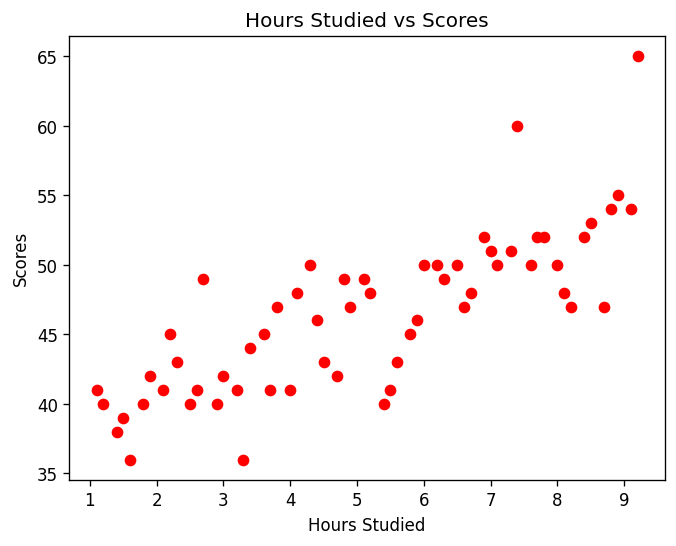

In [22]:
plt.scatter(X_s, y_s, color = "red")
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.title('Hours Studied vs Scores')
plt.show()

### 3.4 Membagi Data Latih dan Data Uji (80:20)
60 data dibagi menjadi 48 data latih dan 12 data uji.

In [23]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size = 0.2, random_state = 42)

print("Jumlah data latih:", len(X_train_s))
print("Jumlah data uji  :", len(X_test_s))

Jumlah data latih: 48
Jumlah data uji  : 12


### 3.5 Melatih Model
Model `LinearRegression()` dilatih memakai data latih.

In [24]:
reg_s = LinearRegression()
reg_s.fit(X_train_s, y_train_s)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 3.6 Menentukan Persamaan Garis Regresi
Intercept (a) dan slope (b) diambil dari model, lalu disusun menjadi persamaan `ŷ = a + bx`.

In [25]:
a_s = reg_s.intercept_
b_s = reg_s.coef_[0]

print("Estimated model intercept, a:", a_s)
print("Estimated model slope, b:", b_s)
print(f"ŷ = {a_s:.2f} + {b_s:.2f}x")

Estimated model intercept, a: 36.46097067904956
Estimated model slope, b: 1.8742157088578226
ŷ = 36.46 + 1.87x


**Interpretasi:** persamaan regresinya `ŷ = 36.46 + 1.87x`.
- Intercept **36.46**: perkiraan nilai jika jam belajar 0.
- Slope **1.87**: setiap tambahan 1 jam belajar, nilai naik sekitar 1.87 poin.

### 3.7 Memprediksi Data Uji dan Membandingkan dengan Nilai Aktual
Model memprediksi nilai untuk 12 data uji, lalu hasilnya disandingkan dengan nilai sebenarnya beserta selisihnya (error).

In [26]:
y_pred_s = reg_s.predict(X_test_s)

hasil_s = pd.DataFrame({
    'Hours': X_test_s.ravel(),
    'Scores Aktual': y_test_s,
    'Scores Prediksi': y_pred_s.round(2),
    'Selisih': (y_test_s - y_pred_s).round(2)
})
print(hasil_s)

    Hours  Scores Aktual  Scores Prediksi  Selisih
0     1.1             41            38.52     2.48
1     1.8             40            39.83     0.17
2     6.0             50            47.71     2.29
3     7.3             51            50.14     0.86
4     2.9             40            41.90    -1.90
5     8.5             53            52.39     0.61
6     5.6             43            46.96    -3.96
7     7.7             52            50.89     1.11
8     2.7             49            41.52     7.48
9     8.9             55            53.14     1.86
10    7.4             60            50.33     9.67
11    8.0             50            51.45    -1.45


### 3.8 Evaluasi Model
Selain R², dihitung juga dua ukuran error:
- **MAE** (Mean Absolute Error): rata-rata selisih mutlak antara nilai aktual dan prediksi.
- **RMSE** (Root Mean Squared Error): akar dari rata-rata kuadrat selisih, lebih sensitif pada error yang besar.

R² pada data latih juga ditampilkan sebagai pembanding.

In [27]:
r2_train_s = r2_score(y_train_s, reg_s.predict(X_train_s))
r2_test_s = r2_score(y_test_s, y_pred_s)
mae_s = mean_absolute_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print("R2 data latih :", round(r2_train_s, 4))
print("R2 data uji   :", round(r2_test_s, 4))
print("MAE data uji  :", round(mae_s, 4))
print("RMSE data uji :", round(rmse_s, 4))

R2 data latih : 0.6316
R2 data uji   : 0.581
MAE data uji  : 2.8187
RMSE data uji : 3.9583


**Interpretasi:**
- R² data uji = **0.5810**: sekitar 58.1% variasi nilai bisa dijelaskan oleh jam belajar. Ini tergolong **sedang**, lebih rendah dibanding data gaji (0.9024).
- MAE **2.82**: rata-rata prediksi meleset sekitar 2.82 poin dari nilai asli. RMSE **3.96**.
- Sisa variasi nilai kemungkinan dipengaruhi faktor lain yang tidak ada di dataset (misalnya kualitas belajar), dan data uji hanya 12 baris sehingga R² mudah berubah.

### 3.9 Visualisasi Hasil pada Data Latih
Titik merah adalah data latih dan garis biru adalah garis regresinya.

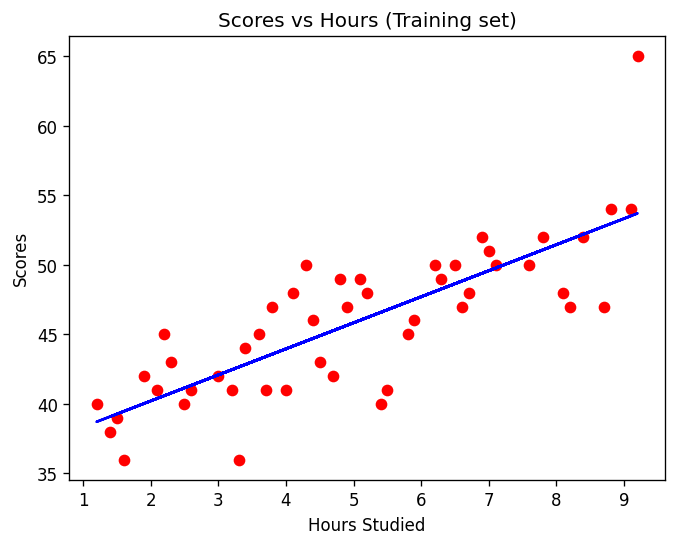

In [28]:
plt.scatter(X_train_s, y_train_s, color = 'red')
plt.plot(X_train_s, reg_s.predict(X_train_s), color = 'blue')
plt.title('Scores vs Hours (Training set)')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.show()

### 3.10 Visualisasi Hasil pada Data Uji
Titik merah adalah data uji. Beberapa titik cukup jauh dari garis (misalnya nilai 60 pada jam belajar 7.4), inilah yang membuat R² data uji tidak setinggi data gaji.

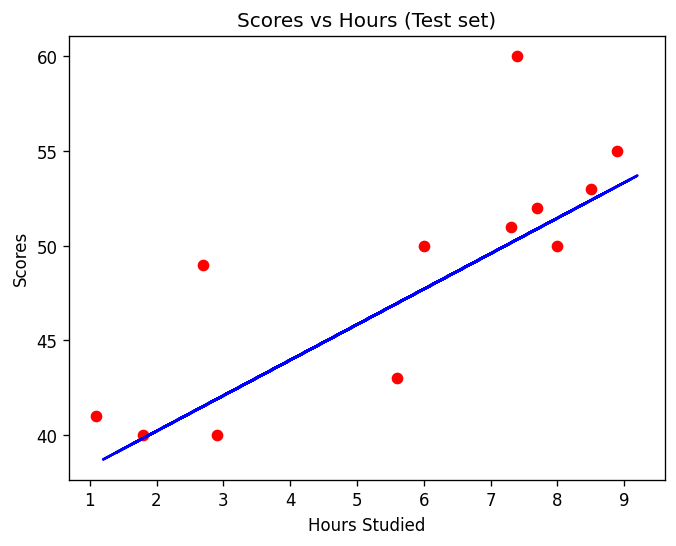

In [29]:
plt.scatter(X_test_s, y_test_s, color = 'red')
plt.plot(X_train_s, reg_s.predict(X_train_s), color = 'blue')
plt.title('Scores vs Hours (Test set)')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.show()

### 3.11 Contoh Prediksi Nilai Baru
Model dipakai untuk memprediksi nilai jika seorang siswa belajar 2, 5, 7.5, dan 9 jam.

In [30]:
jam_baru = np.array([[2], [5], [7.5], [9]])
nilai_prediksi = reg_s.predict(jam_baru)

for jam, nilai in zip(jam_baru.ravel(), nilai_prediksi):
    print(f"Belajar {jam} jam -> prediksi nilai: {nilai:.2f}")

Belajar 2.0 jam -> prediksi nilai: 40.21
Belajar 5.0 jam -> prediksi nilai: 45.83
Belajar 7.5 jam -> prediksi nilai: 50.52
Belajar 9.0 jam -> prediksi nilai: 53.33


## 4. Tugas 2: Multiple Linear Regression (Prediksi Sales Berdasarkan Data Marketing)
**Soal:** prediksi `sales` (y) berdasarkan anggaran iklan (X) di `youtube`, `facebook`, dan `newspaper` memakai dataset `Marketing_Data.csv`.

### 4.1 Load dan Cek Dataset
Sama seperti Tugas 1, data dicek dulu: 5 baris pertama, ukuran data, data kosong, dan statistik ringkas.

In [31]:
df_m = pd.read_csv('Marketing_Data.csv')
print(df_m.head())
print("\nJumlah baris dan kolom:", df_m.shape)
print("Jumlah missing value  :", df_m.isnull().sum().sum())
print("\nStatistik deskriptif:")
print(df_m.describe().round(2))

   youtube  facebook  newspaper  sales
0    84.72     19.20      48.96  12.60
1   351.48     33.96      51.84  25.68
2   135.48     20.88      46.32  14.28
3   116.64      1.80      36.00  11.52
4   318.72     24.00       0.36  20.88

Jumlah baris dan kolom: (171, 4)
Jumlah missing value  : 0

Statistik deskriptif:
       youtube  facebook  newspaper   sales
count   171.00    171.00     171.00  171.00
mean    178.02     27.67      35.24   16.92
std     102.45     17.91      24.90    6.31
min       0.84      0.00       0.36    1.92
25%      91.08     11.70      13.74   12.54
50%     179.76     26.76      31.08   15.48
75%     262.98     43.68      50.88   20.82
max     355.68     59.52     121.08   32.40


**Interpretasi:** data terdiri dari **171 baris** dan 4 kolom (3 predictor dan 1 target), tanpa data kosong, jadi siap dipakai.

### 4.2 Visualisasi Hubungan Setiap Iklan dengan Sales
Karena predictornya ada 3, grafiknya dibuat 3 buah: masing-masing menunjukkan hubungan satu jenis iklan dengan `sales`. YouTube dan Facebook terlihat naik searah dengan sales, sedangkan Newspaper polanya paling acak.

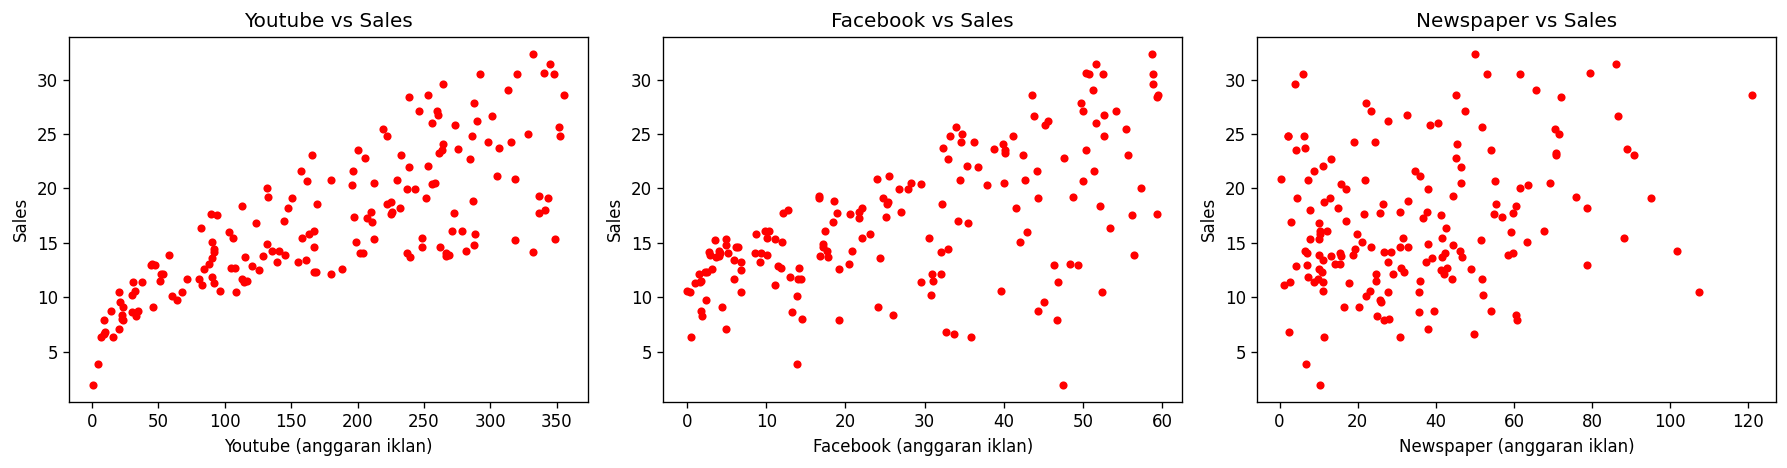

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, kolom in zip(axes, ['youtube', 'facebook', 'newspaper']):
    ax.scatter(df_m[kolom], df_m['sales'], color='red', s=15)
    ax.set_xlabel(kolom.capitalize() + ' (anggaran iklan)')
    ax.set_ylabel('Sales')
    ax.set_title(kolom.capitalize() + ' vs Sales')
plt.tight_layout()
plt.show()

### 4.3 Korelasi Antar Variabel
`df_m.corr()` menghitung koefisien korelasi (-1 sampai 1) antar kolom, ditampilkan sebagai heatmap. Makin mendekati 1, makin kuat hubungan positifnya.

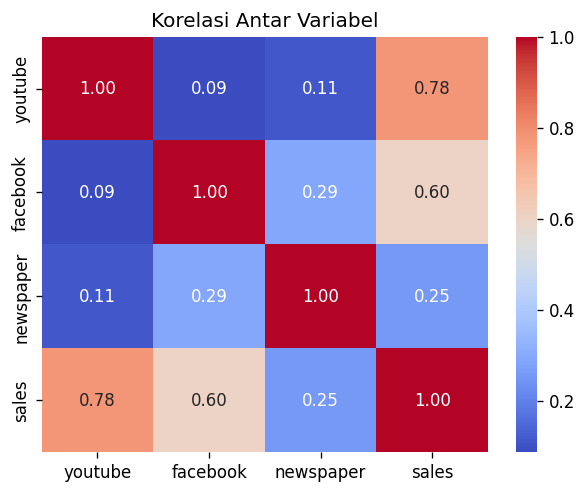

In [33]:
plt.figure(figsize=(6, 4.5))
sns.heatmap(df_m.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.show()

**Interpretasi:** korelasi terhadap sales: **youtube 0.78** (kuat), **facebook 0.60** (sedang), **newspaper 0.25** (lemah). Korelasi antar iklan sendiri rendah, jadi ketiganya tidak saling tumpang tindih. Korelasi hanya menunjukkan hubungan, belum tentu sebab akibat.

### 4.4 Menentukan Predictor (X) dan Target (y)
`iloc[:, :-1]` mengambil 3 kolom pertama (youtube, facebook, newspaper) sebagai **X**, dan `iloc[:, -1]` mengambil kolom terakhir (sales) sebagai **y**.

In [34]:
X_m = df_m.iloc[:, :-1]
y_m = df_m.iloc[:, -1]

print("Predictor (X):", list(X_m.columns))
print("Target (y)   :", y_m.name)

Predictor (X): ['youtube', 'facebook', 'newspaper']
Target (y)   : sales


### 4.5 Membagi Data Latih dan Data Uji (80:20)
171 data dibagi menjadi 136 data latih dan 35 data uji.

In [35]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size = 0.2, random_state = 42)

print("Jumlah data latih:", len(X_train_m))
print("Jumlah data uji  :", len(X_test_m))

Jumlah data latih: 136
Jumlah data uji  : 35


### 4.6 Melatih Model
Model `LinearRegression()` dilatih dengan 3 predictor sekaligus.

In [36]:
reg_m = LinearRegression()
reg_m.fit(X_train_m, y_train_m)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 4.7 Menentukan Persamaan Regresi
Ada 3 koefisien yang urutannya sesuai kolom X: `b1` untuk youtube, `b2` untuk facebook, `b3` untuk newspaper.

In [37]:
a_m = reg_m.intercept_
b1, b2, b3 = reg_m.coef_

print("Estimated model intercept, a:", a_m)
print("Estimated model slope, b1 (youtube)  :", b1)
print("Estimated model slope, b2 (facebook) :", b2)
print("Estimated model slope, b3 (newspaper):", b3)
print(f"ŷ = {a_m:.4f} {b1:+.4f}x1 {b2:+.4f}x2 {b3:+.4f}x3")

Estimated model intercept, a: 3.7030498901645945
Estimated model slope, b1 (youtube)  : 0.0441858407408404
Estimated model slope, b2 (facebook) : 0.19448197522021857
Estimated model slope, b3 (newspaper): -4.883410929941754e-05
ŷ = 3.7030 +0.0442x1 +0.1945x2 -0.0000x3


**Interpretasi:** persamaannya `ŷ = 3.7030 + 0.0442x1 + 0.1945x2 - 0.0000x3` dengan x1 = youtube, x2 = facebook, x3 = newspaper.
- **Intercept 3.7030**: perkiraan sales jika ketiga anggaran iklan 0.
- **b1 = 0.0442**: tiap tambahan 1 satuan anggaran YouTube, sales naik sekitar 0.0442.
- **b2 = 0.1945**: tiap tambahan 1 satuan anggaran Facebook, sales naik sekitar 0.1945 (dampak per satuan paling besar).
- **b3 mendekati 0**: anggaran Newspaper hampir tidak berpengaruh terhadap sales jika YouTube dan Facebook sudah dipakai.

### 4.8 Memprediksi Data Uji
Model memprediksi sales untuk 35 data uji. Berikut 10 baris pertama yang dibandingkan dengan sales aktual.

In [38]:
y_pred_m = reg_m.predict(X_test_m)

hasil_m = pd.DataFrame({
    'Sales Aktual': y_test_m.values,
    'Sales Prediksi': y_pred_m.round(2)
})
print(hasil_m.head(10))

   Sales Aktual  Sales Prediksi
0          1.92           12.98
1         26.04           25.06
2         18.24           18.24
3         20.52           20.63
4         12.36           11.59
5         10.44            8.56
6         14.28           13.35
7         23.52           23.17
8         11.52           12.03
9         24.96           24.96


### 4.9 Evaluasi Model
R² data latih dan data uji dibandingkan untuk melihat apakah model overfitting. MAE dan RMSE menunjukkan besar rata-rata error dalam satuan sales.

In [39]:
r2_train_m = r2_score(y_train_m, reg_m.predict(X_train_m))
r2_test_m = r2_score(y_test_m, y_pred_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

print("R2 data latih :", round(r2_train_m, 4))
print("R2 data uji   :", round(r2_test_m, 4))
print("MAE data uji  :", round(mae_m, 4))
print("RMSE data uji :", round(rmse_m, 4))

R2 data latih : 0.9075
R2 data uji   : 0.8729
MAE data uji  : 1.4034
RMSE data uji : 2.3615


**Interpretasi:**
- R² data uji = **0.8729**: sekitar 87.3% variasi sales dapat dijelaskan oleh anggaran iklan YouTube, Facebook, dan Newspaper. Model tergolong **baik**.
- R² data latih (0.9075) dan data uji (0.8729) tidak berbeda jauh, jadi model tidak overfitting.
- MAE **1.40** dan RMSE **2.36**: rata-rata prediksi meleset sekitar 1.4 satuan sales.

### 4.10 Visualisasi Sales Aktual vs Prediksi
Pada Multiple Linear Regression tidak bisa digambar satu garis di grafik 2D, jadi dipakai grafik **aktual vs prediksi**. Garis biru adalah garis ideal (prediksi sama dengan aktual). Makin dekat titik merah ke garis biru, makin akurat prediksinya.

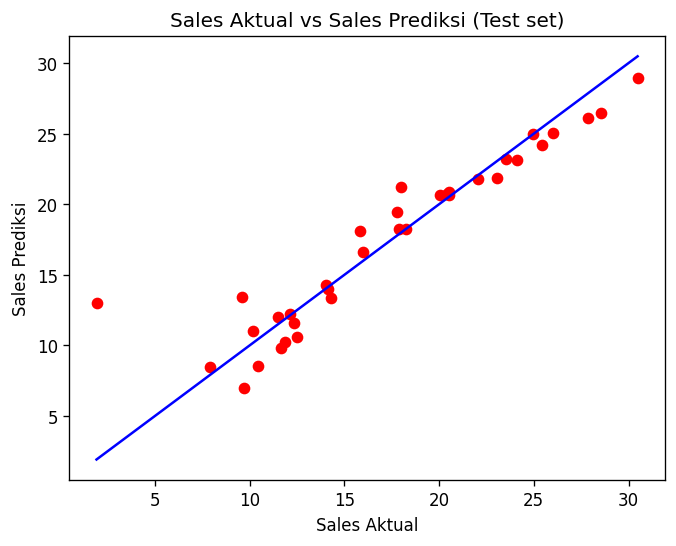

In [40]:
plt.scatter(y_test_m, y_pred_m, color = 'red')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], color = 'blue')
plt.title('Sales Aktual vs Sales Prediksi (Test set)')
plt.xlabel('Sales Aktual')
plt.ylabel('Sales Prediksi')
plt.show()

### 4.11 Contoh Prediksi Data Baru
Misalnya anggaran iklan: YouTube 200, Facebook 30, Newspaper 20. Model memprediksi sales untuk kombinasi tersebut.

In [41]:
data_baru = pd.DataFrame([[200, 30, 20]], columns=X_m.columns)
print("Prediksi sales:", reg_m.predict(data_baru)[0].round(2))

Prediksi sales: 18.37


## 5. Kesimpulan

**Tabel 2. Ringkasan hasil seluruh model**

| Model | Persamaan regresi | R² data uji | Kategori |
|---|---|---|---|
| SLR Salary (praktikum) | ŷ = 25321.58 + 9423.82x | 0.9024 | Sangat baik |
| MLR Income (praktikum) | ŷ = 31465.06 - 101.06x1 + 2154.81x2 | 0.9387 | Sangat baik |
| SLR Student Score (tugas 1) | ŷ = 36.46 + 1.87x | 0.5810 | Sedang |
| MLR Marketing (tugas 2) | ŷ = 3.7030 + 0.0442x1 + 0.1945x2 - 0.0000x3 | 0.8729 | Baik |

- Simple Linear Regression memakai 1 predictor, Multiple Linear Regression memakai lebih dari 1 predictor, dan keduanya dilatih dengan fungsi `LinearRegression()` yang sama.
- Pada **Tugas 1**, jam belajar berpengaruh positif terhadap nilai (setiap 1 jam belajar menaikkan nilai sekitar 1.87 poin), namun R² hanya 0.5810 sehingga masih ada faktor lain yang memengaruhi nilai.
- Pada **Tugas 2**, iklan **Facebook** dan **YouTube** berpengaruh positif terhadap sales, sedangkan **Newspaper** hampir tidak berpengaruh. Model menjelaskan 87.3% variasi sales.